### **LIBRARIES IMPORTING**

In [1]:
!pip install -q keras-cv

In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import keras_cv
from tensorflow import keras
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import confusion_matrix

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# **METRICS**

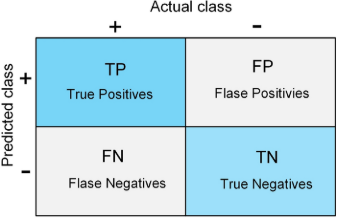

TP (True Positives): Dự đoán là lớp dương (mắc bệnh) và đúng

FP (False Positives): Dự đoán là lớp dương (mắc bệnh) và sai (đúng phải là không mắc bệnh)

TN (True Negatives): Dự đoán là lớp âm (không mắc bệnh) và đúng

FN (False Negatives): Dự đoán là lớp âm (không mắc bệnh) và sai (đúng phải là mắc bệnh)

In [3]:
def metrics(y_true, y_pred):
    print(np.sum((y_true == 0) & (y_pred == 0)))
    print(np.sum((y_true == 0) & (y_pred == 1)))
    print(np.sum((y_true == 1) & (y_pred == 0)))
    print(np.sum((y_true == 1) & (y_pred == 1)))
    

## **Accuracy**

$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$

In [4]:
from sklearn.metrics import accuracy_score

## **Precision**

Precision đo lường tỷ lệ các dự đoán dương (Positive) thực sự đúng, tức là trong số các mẫu được dự đoán là Positive, có bao nhiêu mẫu thực sự là Positive.

$\text{Precision} = \frac{TP}{TP + FP}$

In [5]:
from sklearn.metrics import precision_score

## **FDR**

FDR dùng để đo tỷ lệ dự đoán dương nhưng thực tế lại âm.

$\text{FDR} = \frac{FP}{TP + FP} = 1 - \text{Precision}$

In [6]:
def fdr(y_true, y_pred):
    FP = np.sum((y_true == 0) & (y_pred == 1))
    TP = np.sum((y_true == 1) & (y_pred == 1))
    
    fdr_ = FP / (FP + TP) if (FP + TP) > 0 else 0
    
    return fdr_

## **Recall**

Recall đo lường khả năng mô hình nhận diện đúng các mẫu dương (positive cases).

$\text{Recall} = \frac{TP}{TP + FN}$

In [7]:
from sklearn.metrics import recall_score

## **FNR**

FNR đo tỷ lệ các mẫu dương thực sự nhưng bị mô hình phân loại sai thành âm tính

$\text{FNR} = \frac{FN}{TP + FN} = 1 - \text{Recall}$

In [8]:
def fnr(y_true, y_pred):
    FN = np.sum((y_true == 1) & (y_pred == 0))
    TP = np.sum((y_true == 1) & (y_pred == 1))
    
    fnr_ = FN / (FN + TP) if (FN + TP) > 0 else 0
    
    return fnr_

## **Specificity**

Specificity đo lường khả năng mô hình nhận diện đúng các mẫu âm

$\text{Specificity} = \frac{TN}{TN + FP}$

In [9]:
def specificity(y_true, y_pred):
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    
    specificity_ = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    return specificity_

## **NPV**

NPV đo lường xác suất một mẫu được dự đoán là âm tính thực sự là âm tính

$\text{NPV} = \frac{TN}{TN + FN}$

In [10]:
def npv(y_true, y_pred):
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    npv_ = TN / (TN + FN) if (TN + FN) > 0 else 0
    
    return npv_

## **F1-Score**

F1-score giúp cân bằng giữa Precision và Recall, đặc biệt hữu ích khi dữ liệu bị lệch (imbalanced data). 

$\text{F1-score} = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2TP}{2TP + FP + FN}$

In [11]:
from sklearn.metrics import f1_score

## **BAcc**

Balanced Accuracy (BAcc) là trung bình cộng của Recall (TPR) và Specificity (TNR), hữu ích khi làm việc với dữ liệu mất cân bằng, giúp đánh giá hiệu suất mô hình một cách công bằng giữa hai lớp.

$\text{BAcc} = \frac{\text{Recall} + \text{Specificity}}{2} = \frac{ \frac{TP}{TP + FN} + \frac{TN}{TN + FP} }{2}$

In [12]:
from sklearn.metrics import balanced_accuracy_score

## **AUC**

AUC là diện tích dưới đường cong ROC (Receiver Operating Characteristic). Nó đo lường khả năng phân biệt giữa hai lớp của mô hình. AUC dao động từ 0.5 (đoán ngẫu nhiên) đến 1.0 (mô hình hoàn hảo). Giá trị càng cao, mô hình càng có khả năng phân biệt tốt giữa hai lớp.

$\text{AUC} = \int_{0}^{1} \text{TPR}(x) \, d\text{FPR}(x)$

In [13]:
from sklearn.metrics import roc_auc_score

## **MCC**

Matthews Correlation Coefficient (MCC) đo lường chất lượng của mô hình phân loại nhị phân, cân bằng giữa tất cả các loại lỗi (TP, FP, TN, FN).

MCC có giá trị từ -1 đến 1:
* MCC = 1: Dự đoán hoàn hảo.
* MCC = 0: Dự đoán ngẫu nhiên.
* MCC = -1: Dự đoán hoàn toàn sai.

$\text{MCC} = \frac{TP \times TN - FP \times FN}{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN + FN)}}$

In [14]:
from sklearn.metrics import matthews_corrcoef

In [15]:
def evaluate_model(y_true, y_pred, name="Model"):
    print(f"\n{name}")
    print('accuracy = {}'.format(accuracy_score(y_test, y_pred)))
    print('precision = {}'.format(precision_score(y_test, y_pred)))
    print('FDR = {}'.format(fdr(y_test, y_pred)))
    print('recall = {}'.format(recall_score(y_test, y_pred)))
    print('FNR = {}'.format(fnr(y_test, y_pred)))
    print('specificity = {}'.format(specificity(y_test, y_pred)))
    print('NPV = {}'.format(npv(y_test, y_pred)))
    print('f1-score = {}'.format(f1_score(y_test, y_pred)))
    print('BAcc = {}'.format(balanced_accuracy_score(y_test, y_pred)))
    print('AUC = {}'.format(roc_auc_score(y_test, y_pred)))
    print('MCC = {}'.format(matthews_corrcoef(y_test, y_pred)))

# **DATASET**

In [16]:
img_size = 128

In [17]:
x_train_cxr = np.load('/kaggle/input/pneumonia-detection-datasets/chest-xray/train/images.npy')
y_train = np.load('/kaggle/input/pneumonia-detection-datasets/chest-xray/train/labels.npy')

x_test_cxr = np.load('/kaggle/input/pneumonia-detection-datasets/chest-xray/test/images.npy')
y_test = np.load('/kaggle/input/pneumonia-detection-datasets/chest-xray/test/labels.npy')

print(np.shape(x_train_cxr))
print(np.shape(y_train))
print(np.shape(x_test_cxr))
print(np.shape(y_test))

(5232, 128, 128, 1)
(5232,)
(624, 128, 128, 1)
(624,)


In [18]:
x_train_cxr = x_train_cxr.reshape(-1, img_size, img_size)
x_train_rgb_cxr = np.stack((x_train_cxr,) * 3, axis=-1)

x_test_cxr = x_test_cxr.reshape(-1, img_size, img_size)
x_test_rgb_cxr = np.stack((x_test_cxr,) * 3, axis=-1)

print(np.shape(x_train_rgb_cxr))
print(np.shape(y_train))
print(np.shape(x_test_rgb_cxr))
print(np.shape(y_test))

(5232, 128, 128, 3)
(5232,)
(624, 128, 128, 3)
(624,)


# **ViT**

In [19]:
IMG_SIZE_VIT = 128

x_train_vit = tf.image.resize(x_train_rgb_cxr, (IMG_SIZE_VIT, IMG_SIZE_VIT))
x_test_vit  = tf.image.resize(x_test_rgb_cxr, (IMG_SIZE_VIT, IMG_SIZE_VIT))

x_train_vit = tf.cast(x_train_vit, tf.float32)
x_test_vit  = tf.cast(x_test_vit, tf.float32)


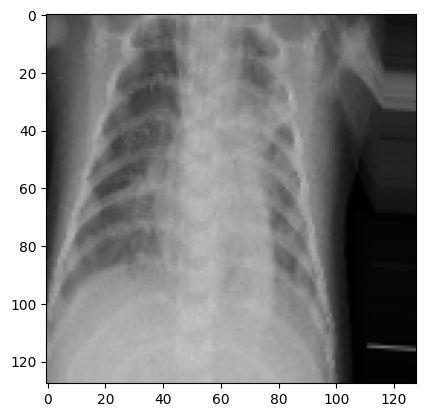

In [20]:
idx = 0
plt.imshow(x_train_rgb_cxr[0], cmap='gray')
plt.show()

In [21]:
!pip install -q transformers timm

In [22]:
import torch
import numpy as np
from transformers import ViTModel, ViTImageProcessor


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = ViTImageProcessor.from_pretrained(
    "google/vit-large-patch16-224-in21k",
    do_rescale=False
)

vit_model = ViTModel.from_pretrained(
    "google/vit-large-patch16-224-in21k"
)

vit_model.to(device)
vit_model.eval()

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/504 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

ViTModel(
  (embeddings): ViTEmbeddings(
    (patch_embeddings): ViTPatchEmbeddings(
      (projection): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ViTEncoder(
    (layer): ModuleList(
      (0-23): 24 x ViTLayer(
        (attention): ViTSdpaAttention(
          (attention): ViTSdpaSelfAttention(
            (query): Linear(in_features=1024, out_features=1024, bias=True)
            (key): Linear(in_features=1024, out_features=1024, bias=True)
            (value): Linear(in_features=1024, out_features=1024, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (output): ViTSelfOutput(
            (dense): Linear(in_features=1024, out_features=1024, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ViTIntermediate(
          (dense): Linear(in_features=1024, out_features=4096, bias=True)
          (intermediate_act_fn

In [24]:
def extract_vit_features(images, batch_size=4):  # rất nhỏ
    features = []

    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]

        inputs = processor(
            images=batch,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = vit_model(**inputs)

        cls_features = outputs.last_hidden_state[:, 0, :]
        features.append(cls_features.cpu().numpy())

    return np.vstack(features)

In [ ]:
def extract_vit_features_with_positions(images, batch_size=4):
    """
    Keep the current CLS feature pipeline unchanged, but also return patch tokens
    and normalized patch positions for later heatmap / gated fusion use.
    """
    cls_features = []
    patch_tokens_list = []
    patch_positions_list = []

    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]

        inputs = processor(
            images=batch,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = vit_model(
                **inputs,
                output_attentions=True,
                return_dict=True
            )

        hidden = outputs.last_hidden_state
        batch_cls = hidden[:, 0, :].cpu().numpy()
        batch_patches = hidden[:, 1:, :].cpu().numpy()

        num_patches = batch_patches.shape[1]
        grid_size = int(np.sqrt(num_patches))
        if grid_size * grid_size != num_patches:
            raise ValueError(f"ViT patch count {num_patches} is not a square grid.")

        rows, cols = np.meshgrid(np.arange(grid_size), np.arange(grid_size), indexing='ij')
        patch_positions = np.stack([
            (rows.flatten() + 0.5) / grid_size,
            (cols.flatten() + 0.5) / grid_size,
        ], axis=1).astype(np.float32)

        for j in range(batch_patches.shape[0]):
            cls_features.append(batch_cls[j])
            patch_tokens_list.append(batch_patches[j])
            patch_positions_list.append(patch_positions)

    return {
        "cls_features": np.vstack(cls_features),
        "patch_tokens": np.array(patch_tokens_list),
        "patch_positions": np.array(patch_positions_list),
    }


# Example usage that does not affect the existing CLS pipeline:
# vit_pack_train = extract_vit_features_with_positions(x_train_rgb)
# vit_pack_test = extract_vit_features_with_positions(x_test_rgb)
# np.save("vit_train_cls.npy", vit_pack_train["cls_features"])
# np.save("vit_test_cls.npy", vit_pack_test["cls_features"])
# np.save("vit_train_patch_tokens.npy", vit_pack_train["patch_tokens"])
# np.save("vit_test_patch_tokens.npy", vit_pack_test["patch_tokens"])
# np.save("vit_train_patch_positions.npy", vit_pack_train["patch_positions"])
# np.save("vit_test_patch_positions.npy", vit_pack_test["patch_positions"])


In [25]:
if x_train_cxr.ndim == 3:
    x_train_rgb = np.stack([x_train_cxr]*3, axis=-1)
    x_test_rgb  = np.stack([x_test_cxr]*3, axis=-1)
else:
    x_train_rgb = x_train_cxr
    x_test_rgb  = x_test_cxr
print(x_train_rgb.shape)
print(x_test_rgb.shape)

(5232, 128, 128, 3)
(624, 128, 128, 3)


In [26]:
x_train_feature_vit = extract_vit_features(x_train_rgb)
x_test_feature_vit  = extract_vit_features(x_test_rgb)

print(x_train_feature_vit.shape)
print(x_test_feature_vit.shape)


(5232, 1024)
(624, 1024)


In [27]:
from sklearn.preprocessing import StandardScaler

scaler_vit = StandardScaler()
x_train_vit_scaled = scaler_vit.fit_transform(x_train_feature_vit)
x_test_vit_scaled  = scaler_vit.transform(x_test_feature_vit)

In [28]:
np.save("vit_train.npy", x_train_vit_scaled)
np.save("vit_test.npy", x_test_vit_scaled)

# **Statistical Radiomics**

In [29]:
# !pip install -q pyradiomics

In [30]:
# from radiomics import featureextractor
# import SimpleITK as sitk

# import radiomics
# radiomics.logger.setLevel(40)  # ERROR only


In [31]:
# from radiomics import featureextractor

# params = {
#     "binWidth": 25,
#     "featureClass": {
#         "firstorder": [],
#         "glcm": [],
#         "glszm": []
#     }
# }


# extractor = featureextractor.RadiomicsFeatureExtractor(**params)


In [32]:
# def extract_radiomics_features(images):
#     features = []

#     for img in images:

#         # ---- Force correct dtype ----
#         if img.dtype != np.uint8:
#             img = (255 * img).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)

#         # ---- Channel handling ----
#         if img.ndim == 3 and img.shape[-1] == 1:
#             img_gray = img.squeeze(-1)
#         elif img.ndim == 3 and img.shape[-1] == 3:
#             img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
#         elif img.ndim == 2:
#             img_gray = img
#         else:
#             raise ValueError(f"Unsupported image shape: {img.shape}")

#         img_gray = img_gray.astype(np.float32)

#         sitk_img = sitk.GetImageFromArray(img_gray)

#         # ---- Valid mask ----
#         mask_array = np.ones_like(img_gray, dtype=np.uint8)
#         mask_array[0, 0] = 0

#         sitk_mask = sitk.GetImageFromArray(mask_array)

#         result = extractor.execute(sitk_img, sitk_mask, label=1)

#         feature_vector = [
#             v for k, v in result.items()
#             if isinstance(v, (int, float))
#         ]

#         features.append(feature_vector)

#     return np.array(features)


In [33]:
# img = x_train_rgb[0]

# if img.shape[-1] == 3:
#     img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
# else:
#     img_gray = img.squeeze()

# mask_array = np.ones_like(img_gray, dtype=np.uint8)
# mask_array[0, 0] = 0

# print("Unique mask values:", np.unique(mask_array))


In [34]:
# x_debug = x_train_rgb[:10]
# test_feat = extract_radiomics_features(x_debug)
# print(test_feat.shape)


In [35]:
# print(x_train_rgb.dtype, x_test_rgb.dtype)

# test_feat = extract_radiomics_features(x_test_rgb[:1])
# print(test_feat.shape)


In [36]:
# x_train_radiomics = extract_radiomics_features(x_train_rgb)
# x_test_radiomics  = extract_radiomics_features(x_test_rgb)

# print("Radiomics train shape:", x_train_radiomics.shape)
# print("Radiomics test shape :", x_test_radiomics.shape)


In [37]:
# scaler_radiomics = StandardScaler()

# x_train_radiomics_scaled = scaler_radiomics.fit_transform(x_train_radiomics)
# x_test_radiomics_scaled  = scaler_radiomics.transform(x_test_radiomics)

# **Wavelet Scattering Transform**

In [38]:
# !pip install -q kymatio

In [39]:
# from kymatio import Scattering2D

In [40]:
# from kymatio import Scattering2D

# def extract_wst_features(images, J=2):
#     features = []

#     scattering = Scattering2D(
#         J=J,
#         shape=images.shape[1:3]
#     )

#     for img in images:

#         # ---- Force dtype ----
#         if img.dtype != np.uint8:
#             img = (255 * img).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)

#         # ---- Grayscale ----
#         if img.ndim == 3 and img.shape[-1] == 3:
#             gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
#         elif img.ndim == 3 and img.shape[-1] == 1:
#             gray = img.squeeze(-1)
#         elif img.ndim == 2:
#             gray = img
#         else:
#             raise ValueError(f"Unsupported image shape {img.shape}")

#         gray = gray.astype(np.float32) / 255.0

#         S = scattering(gray)
#         features.append(S.flatten())

#     return np.array(features)


In [41]:
# test_wst = extract_wst_features(x_test_rgb[:1])
# print(test_wst.shape)


In [42]:
# x_train_wst = extract_wst_features(x_train_rgb)
# x_test_wst  = extract_wst_features(x_test_rgb)

# print("WST train shape:", x_train_wst.shape)
# print("WST test shape:", x_test_wst.shape)

In [43]:
# scaler_wst = StandardScaler()

# x_train_wst_scaled = scaler_radiomics.fit_transform(x_train_wst)
# x_test_wst_scaled  = scaler_radiomics.transform(x_test_wst)

In [44]:
# x_train_fused = np.concatenate(
#     [x_train_vit_scaled, x_train_radiomics_scaled, x_train_wst_scaled],
#     axis=1
# )

# x_test_fused = np.concatenate(
#     [x_test_vit_scaled, x_test_radiomics_scaled, x_test_wst_scaled],
#     axis=1
# )

# print("Fused train shape:", x_train_fused.shape)
# print("Fused test shape:", x_test_fused.shape)


In [45]:
from collections import Counter
n_samples = len(y_train)

# Đếm số lượng mẫu trong từng lớp
class_counts = Counter(y_train)  # Tạo dictionary {0: số lượng, 1: số lượng}
n_classes = len(class_counts)  # Số lớp (ở đây là 2: 0 và 1)

# Tính trọng số cho từng lớp
class_weights = {cls: n_samples / (n_classes * count) for cls, count in class_counts.items()}

# In kết quả
print("Số lượng mẫu mỗi lớp:", class_counts)
print("Trọng số tính toán:", class_weights)

print(y_train.shape)
print("Images for Train", np.shape(x_train_feature_vit))

print(y_test.shape)
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [4, 5, 6],
    'criterion': ['entropy'],
    'min_samples_split': [20, 30, 40],
    'min_samples_leaf': [6, 8, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight = class_weights), 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    verbose=4
)

grid_search.fit(x_train_vit_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
# rf_fused = RandomForestClassifier(
#     n_estimators=300,        # số cây
#     max_depth=None,          # để cây tự học
#     min_samples_split=2,
#     min_samples_leaf=1,
#     max_features="sqrt",     # rất quan trọng
#     class_weight="balanced", # dữ liệu X-ray thường lệch lớp
#     random_state=42,
#     n_jobs=-1
# )

# rf_fused.fit(x_train_vit_scaled, y_train)
# y_pred = rf_fused.predict(x_test_vit_scaled)

Số lượng mẫu mỗi lớp: Counter({1.0: 3883, 0.0: 1349})
Trọng số tính toán: {1.0: 0.6737058975019315, 0.0: 1.939214232765011}
(5232,)
Images for Train (5232, 1024)
(624,)
Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV 1/5] END criterion=entropy, max_depth=4, max_features=sqrt, min_samples_leaf=6, min_samples_split=20, n_estimators=300;, score=0.887 total time=  17.1s
[CV 2/5] END criterion=entropy, max_depth=4, max_features=sqrt, min_samples_leaf=6, min_samples_split=20, n_estimators=300;, score=0.882 total time=  17.2s
[CV 3/5] END criterion=entropy, max_depth=4, max_features=sqrt, min_samples_leaf=6, min_samples_split=20, n_estimators=300;, score=0.872 total time=  17.0s
[CV 4/5] END criterion=entropy, max_depth=4, max_features=sqrt, min_samples_leaf=6, min_samples_split=20, n_estimators=300;, score=0.876 total time=  17.1s
[CV 5/5] END criterion=entropy, max_depth=4, max_features=sqrt, min_samples_leaf=6, min_samples_split=20, n_estimators=300;, score=0.895 total t

## **KNN**

In [46]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)

grid_knn.fit(x_train_vit_scaled, y_train)
print("Best KNN params:", grid_knn.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best KNN params: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}


## **Logistic Regression**

In [47]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
}

grid_lr = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ),
    param_grid_lr,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)

grid_lr.fit(x_train_vit_scaled, y_train)
print("Best LR params:", grid_lr.best_params_)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best LR params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}


## **Linear SVM**

In [48]:
param_grid_svm_linear = {
    'C': [0.01, 0.1, 1, 10]
}

grid_svm_linear = GridSearchCV(
    SVC(
        kernel='linear',
        class_weight='balanced'
    ),
    param_grid_svm_linear,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)

grid_svm_linear.fit(x_train_vit_scaled, y_train)
print("Best Linear SVM params:", grid_svm_linear.best_params_)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Linear SVM params: {'C': 0.01}


## **RBF-SVM**

In [49]:
param_grid_svm_rbf = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001]
}

grid_svm_rbf = GridSearchCV(
    SVC(
        kernel='rbf',
        class_weight='balanced'
    ),
    param_grid_svm_rbf,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)

grid_svm_rbf.fit(x_train_vit_scaled, y_train)
print("Best RBF-SVM params:", grid_svm_rbf.best_params_)


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best RBF-SVM params: {'C': 1, 'gamma': 0.001}


In [50]:
models = {
    "KNN": grid_knn.best_estimator_,
    "Logistic Regression": grid_lr.best_estimator_,
    "Linear SVM": grid_svm_linear.best_estimator_,
    "RBF-SVM": grid_svm_rbf.best_estimator_,
    "Random Forest": grid_search.best_estimator_
}

for name, model in models.items():
    y_pred = model.predict(x_test_vit_scaled)
    evaluate_model(y_test, y_pred, name)



KNN
accuracy = 0.875
precision = 0.8786407766990292
FDR = 0.12135922330097088
recall = 0.9282051282051282
FNR = 0.07179487179487179
specificity = 0.7863247863247863
NPV = 0.8679245283018868
f1-score = 0.9027431421446385
BAcc = 0.8572649572649573
AUC = 0.8572649572649573
MCC = 0.7303719898608544

Logistic Regression
accuracy = 0.9262820512820513
precision = 0.9257425742574258
FDR = 0.07425742574257425
recall = 0.958974358974359
FNR = 0.041025641025641026
specificity = 0.8717948717948718
NPV = 0.9272727272727272
f1-score = 0.9420654911838792
BAcc = 0.9153846153846155
AUC = 0.9153846153846155
MCC = 0.8418187844700239

Linear SVM
accuracy = 0.9182692307692307
precision = 0.9357326478149101
FDR = 0.06426735218508997
recall = 0.9333333333333333
FNR = 0.06666666666666667
specificity = 0.8931623931623932
NPV = 0.8893617021276595
f1-score = 0.9345314505776636
BAcc = 0.9132478632478633
AUC = 0.9132478632478633
MCC = 0.8257947409515898

RBF-SVM
accuracy = 0.9230769230769231
precision = 0.9071428

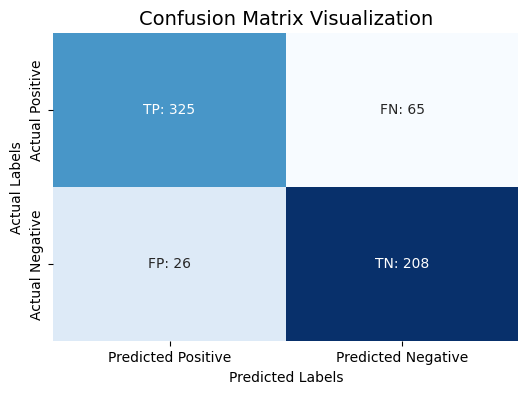

In [51]:
# Tạo confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Tạo ma trận hiển thị
matrix = np.array([[f"TP: {tp}", f"FN: {fn}"],
                   [f"FP: {fp}", f"TN: {tn}"]])

# Vẽ bảng confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=matrix, fmt="", cmap="Blues", cbar=False, xticklabels=["Predicted Positive", "Predicted Negative"], yticklabels=["Actual Positive", "Actual Negative"])

# Tiêu đề
plt.title("Confusion Matrix Visualization", fontsize=14)
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")

# Hiển thị biểu đồ
plt.show()

In [ ]:
# =========================================================
# PATCH-LEVEL VIT FEATURES WITH POSITIONS
# =========================================================
# Add this cell at the end to keep the current CLS-feature pipeline unchanged.
# It exposes patch tokens and their spatial coordinates for later heatmap work.

import numpy as np
import torch
import cv2
from PIL import Image


def ensure_rgb_image_for_patch(image):
    if isinstance(image, Image.Image):
        return image.convert('RGB')

    image = np.asarray(image)
    if image.ndim == 2:
        image = np.stack([image] * 3, axis=-1)
    elif image.shape[-1] == 1:
        image = np.repeat(image, 3, axis=-1)

    if image.dtype != np.uint8:
        image = image.astype(np.float32)
        image = image - image.min()
        image = image / (image.max() + 1e-8)
        image = (image * 255).astype(np.uint8)

    return Image.fromarray(image).convert('RGB')


def _get_vit_outputs(image, model=vit_model, processor=processor, device=device):
    image = ensure_rgb_image_for_patch(image)
    inputs = processor(images=image, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True, return_dict=True)
    return outputs


def get_vit_patch_positions(image, model=vit_model, processor=processor, device=device):
    """
    Return ViT patch tokens plus their 2D positions without changing the CLS pipeline.
    Output:
    - patch_tokens: (num_patches, hidden_dim)
    - patch_positions: (num_patches, 2) normalized row/col centers in [0, 1]
    - cls_token: (hidden_dim,)
    """
    outputs = _get_vit_outputs(image, model=model, processor=processor, device=device)
    hidden = outputs.last_hidden_state[0]  # (1 + num_patches, hidden_dim)
    cls_token = hidden[0].detach().cpu().numpy()
    patch_tokens = hidden[1:].detach().cpu().numpy()

    num_patches = patch_tokens.shape[0]
    grid_size = int(np.sqrt(num_patches))
    if grid_size * grid_size != num_patches:
        raise ValueError(f'ViT patch count {num_patches} is not a square grid.')

    rows, cols = np.meshgrid(np.arange(grid_size), np.arange(grid_size), indexing='ij')
    patch_positions = np.stack([
        (rows.flatten() + 0.5) / grid_size,
        (cols.flatten() + 0.5) / grid_size,
    ], axis=1)

    return {
        'cls_token': cls_token,
        'patch_tokens': patch_tokens,
        'patch_positions': patch_positions,
        'grid_size': grid_size,
        'attentions': outputs.attentions,
    }


def compute_attention_rollout(attentions):
    if not isinstance(attentions, tuple):
        attentions = (attentions,)

    rollout = torch.eye(attentions[0].shape[-1], device=attentions[0].device)
    for attention in attentions:
        attn = attention.mean(dim=1)[0]
        attn = attn + torch.eye(attn.shape[-1], device=attn.device)
        attn = attn / attn.sum(dim=-1, keepdim=True)
        rollout = attn @ rollout

    cls_to_patch = rollout[0, 1:]
    grid_size = int(np.sqrt(cls_to_patch.shape[0]))
    heatmap = cls_to_patch.reshape(grid_size, grid_size).detach().cpu().numpy()
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()
    return heatmap


def get_vit_patch_importance_map(image, model=vit_model, processor=processor, device=device):
    """
    Better patch importance map using CLS-to-patch attention rollout.
    This keeps the spatial positions and produces a more meaningful heatmap than token norms.
    """
    pack = get_vit_patch_positions(image, model=model, processor=processor, device=device)
    patch_tokens = pack['patch_tokens']
    grid_size = pack['grid_size']
    attentions = pack['attentions']

    rollout_map = compute_attention_rollout(attentions)
    token_energy = np.linalg.norm(patch_tokens, axis=1).reshape(grid_size, grid_size)
    token_energy = (token_energy - token_energy.min()) / (token_energy.max() - token_energy.min() + 1e-8)

    # Blend attention with token energy so the result is less noisy than norms alone.
    scores = 0.8 * rollout_map + 0.2 * token_energy
    scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)

    return scores, pack['patch_positions']


def make_patch_heatmap_overlay(image, alpha=0.45):
    patch_map, _ = get_vit_patch_importance_map(image)
    image_rgb = ensure_rgb_image_for_patch(image)
    image_np = np.array(image_rgb)
    patch_map_up = cv2.resize(patch_map, (image_np.shape[1], image_np.shape[0]), interpolation=cv2.INTER_CUBIC)
    patch_map_up = np.clip(patch_map_up, 0.0, 1.0)
    colored = cv2.applyColorMap(np.uint8(255 * patch_map_up), cv2.COLORMAP_JET)
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(image_np, 1 - alpha, colored, alpha, 0)
    return patch_map_up, overlay


# Example usage that does not affect the existing cells:
# sample_idx = 0
# patch_map, patch_positions = get_vit_patch_importance_map(x_test_rgb[sample_idx])
# patch_map_up, overlay = make_patch_heatmap_overlay(x_test_rgb[sample_idx])
# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
# plt.imshow(x_test_rgb[sample_idx])
# plt.axis('off')
# plt.subplot(1, 2, 2)
# plt.imshow(overlay)
# plt.axis('off')
# plt.show()

In [ ]:
# -------------------------
# Linear probe (patch-avg) + patch-gradcam utilities
# -------------------------
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


class LinearProbe(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim, 1)

    def forward(self, x):
        return self.fc(x).view(-1, 1)


def train_linear_probe_on_patch_avg(images, labels, probe=None, epochs=5, batch_size=32, lr=1e-3, device=device, sample_limit=None):
    """Train a frozen-ViT linear probe on the mean of patch tokens (patch-avg).
    Returns the trained probe (on device).
    images: numpy array or list of images understood by `processor`.
    labels: numpy array of 0/1 labels.
    sample_limit: if set, trains on first N samples for quick experiment.
    """
    if sample_limit is not None:
        images = images[:sample_limit]
        labels = labels[:sample_limit]

    # collect patch-avg features (freeze ViT)
    feats = []
    labs = []
    vit_model.eval()
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        inputs = processor(images=batch, return_tensors='pt').to(device)
        with torch.no_grad():
            outputs = vit_model(**inputs, return_dict=True)
        hidden = outputs.last_hidden_state  # (B, 1 + P, D)
        patch_tokens = hidden[:, 1:, :]
        patch_avg = patch_tokens.mean(dim=1)  # (B, D)
        feats.append(patch_avg.cpu())
        labs.append(torch.tensor(labels[i:i+batch_size], dtype=torch.float32).unsqueeze(1))

    X = torch.cat(feats, dim=0)
    Y = torch.cat(labs, dim=0)

    dataset = TensorDataset(X, Y)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    in_dim = X.shape[1]
    if probe is None:
        probe = LinearProbe(in_dim).to(device)
    else:
        probe.to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimr = optim.Adam(probe.parameters(), lr=lr)

    probe.train()
    for ep in range(epochs):
        epoch_loss = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimr.zero_grad()
            logits = probe(xb)  # (B,1)
            loss = criterion(logits, yb)
            loss.backward()
            optimr.step()
            epoch_loss += loss.item() * xb.size(0)
        epoch_loss /= len(dataset)
    probe.eval()
    return probe


def compute_patch_gradcam(image, probe, device=device):
    """Compute patch-level Grad-CAM style importance using a probe trained on patch-avg.
    Returns normalized grid heatmap (grid_size x grid_size).
    """
    vit_model.eval()
    img = ensure_rgb_image_for_patch(image)
    inputs = processor(images=img, return_tensors='pt').to(device)

    # get patch tokens for single image
    with torch.no_grad():
        outputs = vit_model(**inputs, return_dict=True)
    hidden = outputs.last_hidden_state[0]  # (1+P, D) -> take index 0
    patch_tokens = hidden[1:, :].detach().to(device)  # (P, D)

    # enable grad on tokens for attribution
    patch_tokens = patch_tokens.clone().requires_grad_(True)

    # compute patch-avg and forward through probe
    patch_avg = patch_tokens.mean(dim=0, keepdim=True)  # (1, D)
    logits = probe(patch_avg)  # (1,1)
    score = logits.squeeze()

    # backward to get gradients wrt patch tokens
    probe.zero_grad()
    if patch_tokens.grad is not None:
        patch_tokens.grad.zero_()
    score.backward(retain_graph=False)

    grads = patch_tokens.grad  # (P, D)
    # importance: elementwise product then L2 norm per patch (grad * activation)
    imp = (grads * patch_tokens).norm(dim=1).detach().cpu().numpy()

    num_patches = imp.shape[0]
    grid_size = int(np.sqrt(num_patches))
    heatmap = imp.reshape(grid_size, grid_size)
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap = heatmap / (heatmap.max() + 1e-8)
    return heatmap


def make_patch_gradcam_overlay(image, probe, alpha=0.45):
    heatmap = compute_patch_gradcam(image, probe)
    image_rgb = ensure_rgb_image_for_patch(image)
    image_np = np.array(image_rgb)
    heat_up = cv2.resize(heatmap, (image_np.shape[1], image_np.shape[0]), interpolation=cv2.INTER_CUBIC)
    heat_up = np.clip(heat_up, 0.0, 1.0)
    colored = cv2.applyColorMap(np.uint8(255 * heat_up), cv2.COLORMAP_JET)
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(image_np, 1 - alpha, colored, alpha, 0)
    return heat_up, overlay


# Quick demo runner (small sample) - adjust sample sizes as needed
def quick_train_and_show(sample_limit=500, epochs=5):
    # prepare labels arrays from notebook variables (y_train, x_train_rgb assumed present)
    X = x_train_rgb if 'x_train_rgb' in globals() else x_train_rgb_cxr
    Y = y_train
    n = min(sample_limit, len(X))
    probe = train_linear_probe_on_patch_avg(X, Y, epochs=epochs, sample_limit=n)

    # show overlays for first 3 validation samples
    for idx in range(3):
        img = x_test_rgb[idx]
        heat_up, overlay = make_patch_gradcam_overlay(img, probe)
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1)
        plt.imshow(img)
        plt.axis('off')
        plt.title('Original')
        plt.subplot(1,2,2)
        plt.imshow(overlay)
        plt.axis('off')
        plt.title(f'Patch-GradCAM (idx={idx})')
        plt.show()


# End of appended utilities